# CIFAR ResNet epoch 144 latent clustering

This notebook loads latent vectors (`a3`, i.e., layer 3) for `resnet_cifar` at epoch 144 from multifield inference outputs in `~/data_2` (fallback: `~/data_1`), runs multiple clustering algorithms, and visualizes:
- class-vs-cluster heatmaps
- dendrograms for hierarchical structure

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

from scipy.cluster.hierarchy import linkage, dendrogram

sns.set_theme(style="whitegrid")

In [3]:
MODEL_DATASET = "resnet_cifar"
SPLIT = "trainUval"
EPOCH = 144
TENSOR_TAG = 3  # a3 corresponds to layer 3 for this run config
SEED = 42

CANDIDATE_ROOTS = [
    Path("~/data_2/tvcg_multifield_infer").expanduser(),
    Path("~/data_1/tvcg_multifield_infer").expanduser(),
]

In [ ]:
from utils import resolve_run_dir, load_epoch_latents_and_labels

In [5]:
run_dir = resolve_run_dir(MODEL_DATASET, CANDIDATE_ROOTS)
X_raw, y = load_epoch_latents_and_labels(run_dir, SPLIT, EPOCH, TENSOR_TAG)

print(f"Using run directory: {run_dir}")
print(f"Latent matrix shape: {X_raw.shape}")
print(f"Labels shape: {y.shape}")
print("Class counts:")
print(pd.Series(y).value_counts().sort_index())

Using run directory: /home/santripta/data_2/tvcg_multifield_infer/resnet_cifar
Latent matrix shape: (60000, 2048)
Labels shape: (60000,)
Class counts:
0    6000
1    6000
2    6000
3    6000
4    6000
5    6000
6    6000
7    6000
8    6000
9    6000
Name: count, dtype: int64


In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

max_dims = min(2048, X_scaled.shape[1], X_scaled.shape[0] - 1)
if max_dims < 2:
    raise ValueError(f"Not enough samples/features for PCA: {X_scaled.shape}")

pca = PCA(n_components=max_dims, random_state=SEED)
X = pca.fit_transform(X_scaled)

print(f"Reduced latent shape: {X.shape}")
print(f"Explained variance ratio sum: {pca.explained_variance_ratio_.sum():.4f}")

Reduced latent shape: (60000, 2048)
Explained variance ratio sum: 1.0000


In [7]:
import pickle as pkl
with open("../../knn_times_tvcg_multifield.pkl", "rb") as f:
    knn_times = pkl.load(f)

[x/60 for x in knn_times[(60000, 2048)]]

[40.85957463663071,
 59.25779532418431,
 115.79948436380364,
 68.14054381516762,
 40.14744237871685,
 116.0085321187973,
 40.825279932438086,
 23.40539885708131,
 113.90437847629656,
 114.67779831119502,
 39.54957381216809,
 113.0759046177535,
 24.585200796167676,
 115.17659962795054,
 34.18708033047927,
 113.29466307112015,
 114.4428492224853,
 115.07195366770028,
 85.4123647621988]

In [9]:
n_classes = int(np.unique(y).shape[0])

clusterers = {
    "KMeans": KMeans(n_clusters=n_classes, random_state=SEED, n_init=20),
    # "GaussianMixture": GaussianMixture(n_components=n_classes, random_state=SEED),
    # "Agglomerative (ward)": AgglomerativeClustering(n_clusters=n_classes, linkage="ward"),
    # "Agglomerative (average-cosine)": AgglomerativeClustering(
    #     n_clusters=n_classes,
    #     linkage="average",
    #     metric="cosine",
    # ),
}

cluster_assignments = {}
scores = []

for name, estimator in clusterers.items():
    if isinstance(estimator, GaussianMixture):
        labels_pred = estimator.fit_predict(X)
    else:
        labels_pred = estimator.fit_predict(X)

    cluster_assignments[name] = labels_pred
    scores.append(
        {
            "algorithm": name,
            "ARI": adjusted_rand_score(y, labels_pred),
            "NMI": normalized_mutual_info_score(y, labels_pred),
            "n_clusters_found": int(np.unique(labels_pred).shape[0]),
        }
    )

scores_df = pd.DataFrame(scores).sort_values("NMI", ascending=False)
scores_df

,algorithm,ARI,NMI,n_clusters_found
0,KMeans,0.476814,0.542687,10


In [13]:
cifar10_class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]

In [14]:
def plot_class_cluster_heatmap(true_labels: np.ndarray, cluster_labels: np.ndarray, title: str) -> None:
    table = pd.crosstab(
        pd.Series(true_labels, name="class"),
        pd.Series(cluster_labels, name="cluster"),
        normalize="index",
    )

    table.index = [
        cifar10_class_names[int(c)] if 0 <= int(c) < len(cifar10_class_names) else str(c)
        for c in table.index
    ]
    plt.figure(figsize=(12, 5))
    sns.heatmap(table, cmap="mako", vmin=0.0, vmax=1.0)
    plt.title(title)
    plt.xlabel("cluster id")
    plt.ylabel("true class")
    plt.tight_layout()
    plt.show()

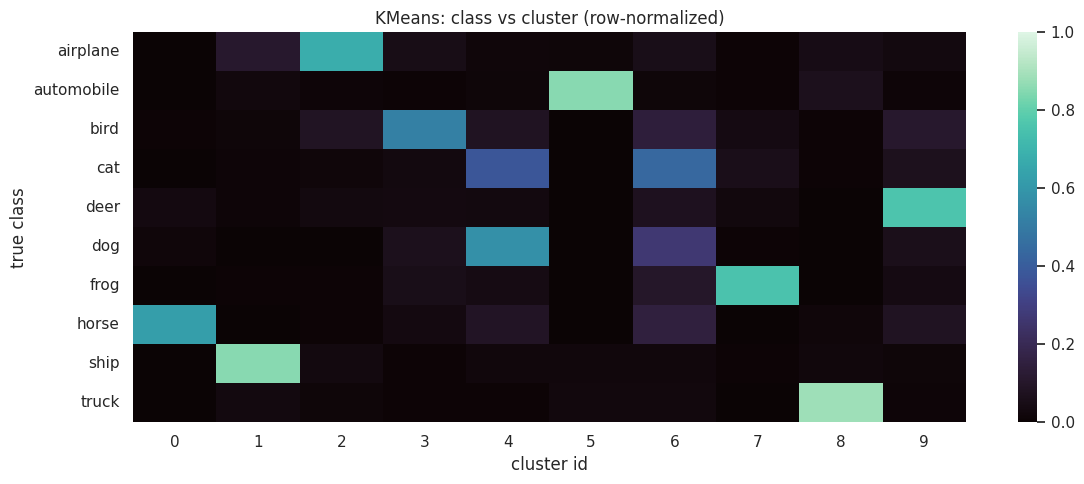

In [15]:
for name, pred in cluster_assignments.items():
    plot_class_cluster_heatmap(y, pred, f"{name}: class vs cluster (row-normalized)")

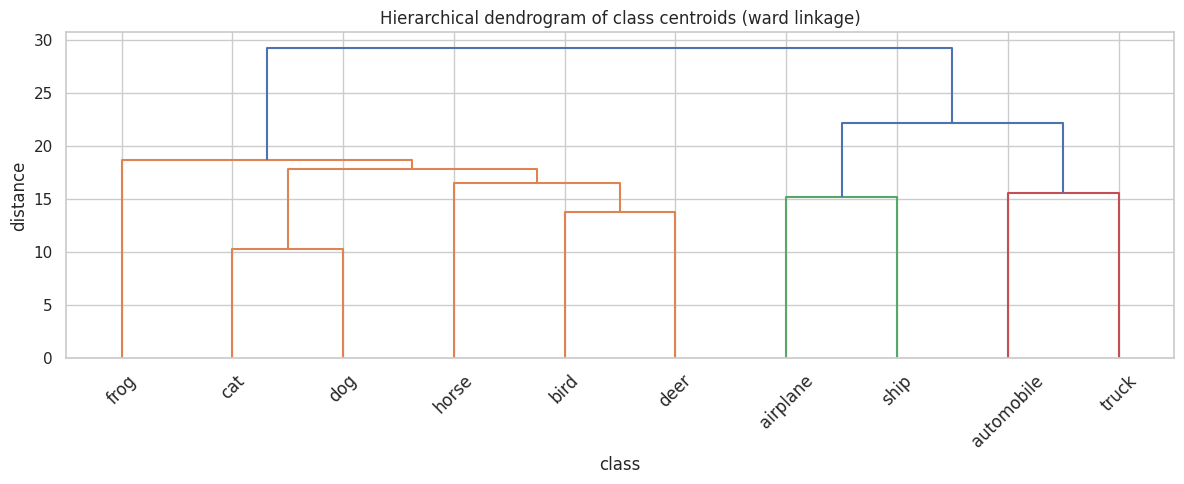

In [18]:
# Dendrogram over class centroids in latent space.
classes = np.sort(np.unique(y))
class_centroids = np.vstack([X[y == c].mean(axis=0) for c in classes])

Z = linkage(class_centroids, method="ward", metric="euclidean")

plt.figure(figsize=(12, 5))
dendrogram(Z, labels=[f"{c}" for c in cifar10_class_names], leaf_rotation=45)
plt.title("Hierarchical dendrogram of class centroids (ward linkage)")
plt.xlabel("class")
plt.ylabel("distance")
plt.tight_layout()
plt.show()

In [21]:
import plotly.figure_factory as ff

rng = np.random.default_rng(SEED)
sample_size = min(400, X.shape[0])
sample_idx = rng.choice(X.shape[0], size=sample_size, replace=False)
X_sample = X[sample_idx]
y_sample = y[sample_idx]

fig = ff.create_dendrogram(
    X_sample,
    labels=[cifar10_class_names[cls] for cls in y_sample],
    linkagefun=lambda x: linkage(x, method="ward", metric="euclidean"),
)

fig.update_layout(
    title=f"Sample-level dendrogram (n={sample_size}, leaf label=true class)",
    width=1600,
    height=600,
    xaxis_title="sample",
    yaxis_title="distance",
)

fig.show()